# 05 — Evaluation & Error Analysis

Task-appropriate metrics (RMSE/MAE/R2 in dollar terms) and a discussion of where and why the model fails.

In [1]:
import sys
sys.path.append('../src')
from utils import *

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')
pd.set_option('display.max_columns', None)

## 1. Load best models + test data


In [2]:
# ── 1. Reload data + reproduce identical splits (same random_state) ──
df = pd.read_csv('../data/processed/airbnb_features.csv')
non_feature_cols = ['price', 'price_log', 'neighbourhood', 'neighbourhood_group',
                     'room_type', 'geo_cluster_raw', 'host_scale_raw']
feature_cols = [c for c in df.columns if c not in non_feature_cols]

X = df[feature_cols]
y = df['price_log']
groups = df['neighbourhood']

from sklearn.model_selection import train_test_split, GroupShuffleSplit

X_train_a, X_test_a, y_train_a, y_test_a, idx_train_a, idx_test_a = train_test_split(
    X, y, df.index, test_size=0.2, random_state=42
)

gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(gss.split(X, y, groups=groups))
X_test_b, y_test_b, idx_test_b = X.iloc[test_idx], y.iloc[test_idx], df.index[test_idx]

print(f"Test A (random): {X_test_a.shape}, Test B (spatial): {X_test_b.shape}")

Test A (random): (9180, 12), Test B (spatial): (7235, 12)


In [3]:
# ── 2. Load saved models ───────────────────────────────────────────
import joblib

ridge_a = joblib.load('../models/ridge_random_split.pkl')
ridge_b = joblib.load('../models/ridge_spatial_split.pkl')
ada_a = joblib.load('../models/adaboost_random_split.pkl')
ada_b = joblib.load('../models/adaboost_spatial_split.pkl')

## 2. Metrics table
RMSE, MAE, R2 — random split vs. grouped split, both model families.

In [6]:
# ── 2. Metrics — log scale AND back-transformed to dollars ────────
def report_both_scales(y_true_log, y_pred_log, label):
    log_metrics = regression_report(y_true_log, y_pred_log, label=f"{label} [log]")
    y_true_usd = np.expm1(y_true_log)
    y_pred_usd = np.expm1(y_pred_log)
    usd_metrics = regression_report(y_true_usd, y_pred_usd, label=f"{label} [USD]")
    return {**{f"log_{k}": v for k, v in log_metrics.items()},
            **{f"usd_{k}": v for k, v in usd_metrics.items()}}

results = {}
results['ridge_random'] = report_both_scales(y_test_a, ridge_a.predict(X_test_a), "Ridge/random")
results['ridge_spatial'] = report_both_scales(y_test_b, ridge_b.predict(X_test_b), "Ridge/spatial")
results['ada_random'] = report_both_scales(y_test_a, ada_a.predict(X_test_a), "AdaBoost/random")
results['ada_spatial'] = report_both_scales(y_test_b, ada_b.predict(X_test_b), "AdaBoost/spatial")

metrics_table = pd.DataFrame(results).T
print(metrics_table)

Ridge/random [log] RMSE: 0.3800 | MAE: 0.2981 | R2: 0.5563
Ridge/random [USD] RMSE: 49.5211 | MAE: 35.0080 | R2: 0.4749
Ridge/spatial [log] RMSE: 0.3844 | MAE: 0.2991 | R2: 0.5786
Ridge/spatial [USD] RMSE: 51.6763 | MAE: 37.2027 | R2: 0.5040
AdaBoost/random [log] RMSE: 0.3828 | MAE: 0.3004 | R2: 0.5500
AdaBoost/random [USD] RMSE: 49.8229 | MAE: 35.3183 | R2: 0.4685
AdaBoost/spatial [log] RMSE: 0.3866 | MAE: 0.3022 | R2: 0.5738
AdaBoost/spatial [USD] RMSE: 52.3746 | MAE: 37.5952 | R2: 0.4905
               log_rmse   log_mae    log_r2   usd_rmse    usd_mae    usd_r2
ridge_random   0.380050  0.298128  0.556333  49.521142  35.007991  0.474886
ridge_spatial  0.384433  0.299064  0.578552  51.676315  37.202682  0.504043
ada_random     0.382757  0.300406  0.549990  49.822897  35.318275  0.468467
ada_spatial    0.386581  0.302237  0.573830  52.374573  37.595209  0.490550


## 3. Residual plots
Predicted vs. actual; residuals vs. key features.

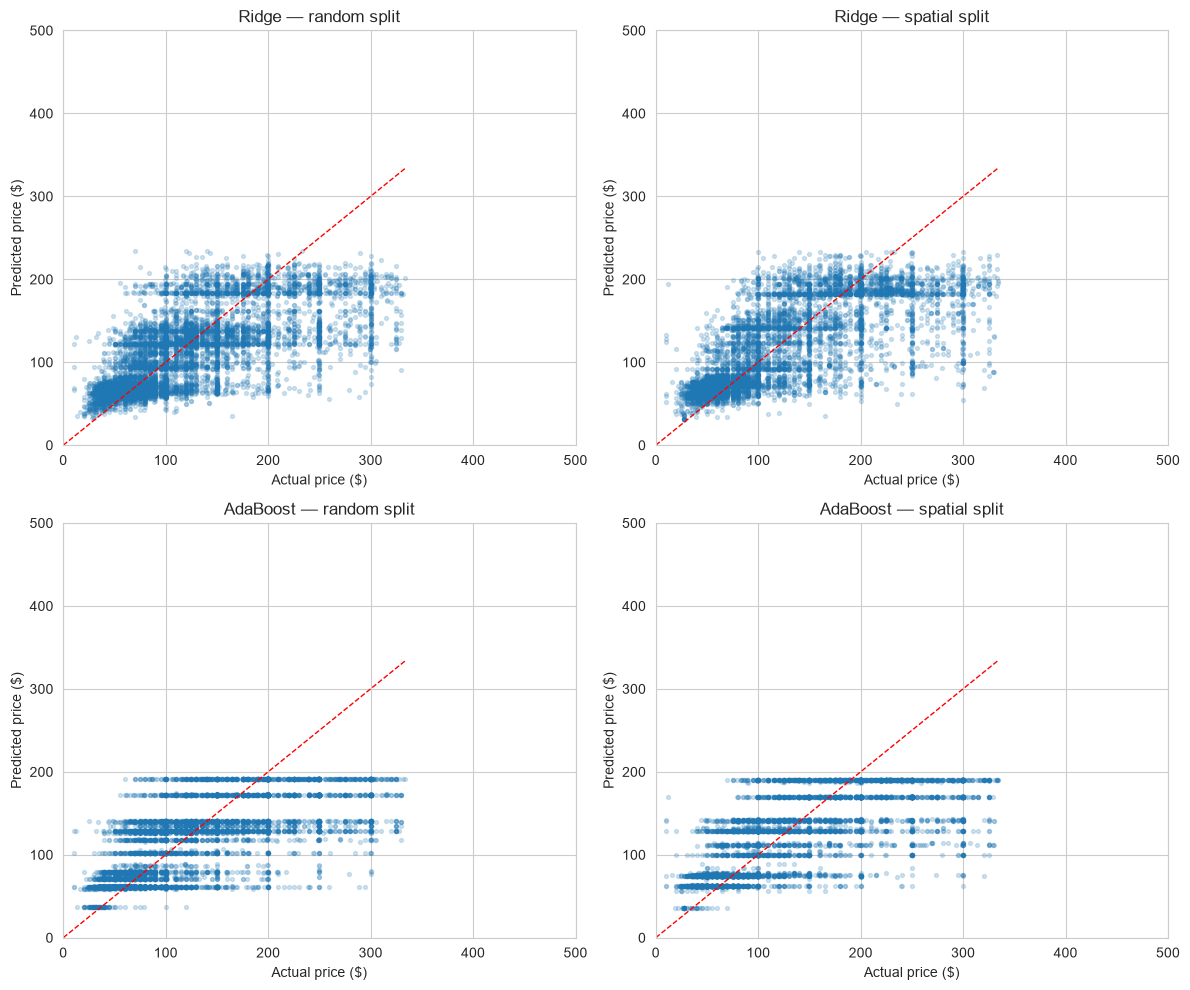

In [ ]:
# ── 3. Residual plots — predicted vs actual, dollar scale ─────────
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
configs = [
    (ridge_a, X_test_a, y_test_a, 'Ridge — random split', axes[0, 0]),
    (ridge_b, X_test_b, y_test_b, 'Ridge — spatial split', axes[0, 1]),
    (ada_a, X_test_a, y_test_a, 'AdaBoost — random split', axes[1, 0]),
    (ada_b, X_test_b, y_test_b, 'AdaBoost — spatial split', axes[1, 1]),
]
for model, X_t, y_t, title, ax in configs:
    y_true_usd = np.expm1(y_t)
    y_pred_usd = np.expm1(model.predict(X_t))
    ax.scatter(y_true_usd, y_pred_usd, alpha=0.2, s=8)
    max_val = max(y_true_usd.max(), y_pred_usd.max())
    ax.plot([0, max_val], [0, max_val], 'r--', linewidth=1)
    ax.set_xlabel('Actual price ($)'); ax.set_ylabel('Predicted price ($)')
    ax.set_title(title)
    ax.set_xlim(0, 500); ax.set_ylim(0, 500)  # crop for readability

plt.tight_layout()
plt.savefig('../figures/predicted_vs_actual.png', dpi=150)
plt.show()

## 4. Error breakdown by segment
By borough/geo-cluster, room type, host-scale bucket. Where is error worst?

In [7]:
# ── 5. Error breakdown by segment ──────────────────────────────────
# Use the best-performing model (adjust based on your Step 3 table)
best_model, X_t, y_t, idx_t, split_label = ada_b, X_test_b, y_test_b, idx_test_b, 'spatial'

pred_usd = np.expm1(best_model.predict(X_t))
true_usd = np.expm1(y_t)
abs_error = np.abs(pred_usd - true_usd)

segment_df = df.loc[idx_t, ['neighbourhood_group', 'room_type', 'host_scale_raw']].copy()
segment_df['abs_error'] = abs_error.values

for col in ['neighbourhood_group', 'room_type', 'host_scale_raw']:
    print(f"\nMean absolute error by {col}:")
    print(segment_df.groupby(col)['abs_error'].agg(['mean', 'count']).sort_values('mean', ascending=False))


Mean absolute error by neighbourhood_group:
                          mean  count
neighbourhood_group                  
Manhattan            39.602098   5319
Staten Island        36.376879     57
Brooklyn             34.917031    733
Bronx                32.813791    216
Queens               29.233334    910

Mean absolute error by room_type:
                      mean  count
room_type                        
Entire home/apt  46.717635   3795
Private room     27.597100   3301
Shared room      25.970426    139

Mean absolute error by host_scale_raw:
                     mean  count
host_scale_raw                  
commercial      43.643582    925
individual      38.196982   4510
small           32.979243   1800


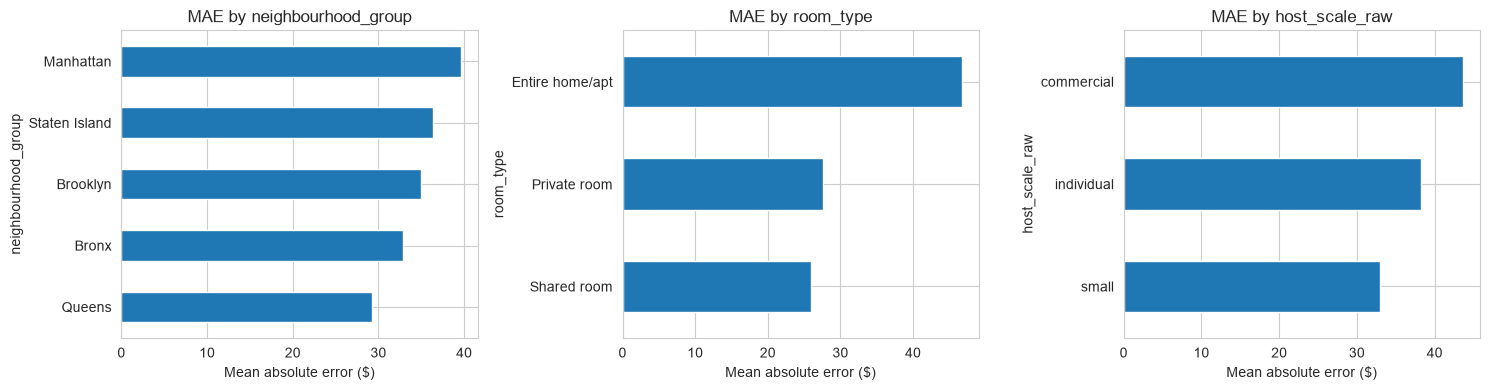

In [8]:
# ── 5b. Visualize error by segment ─────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, ['neighbourhood_group', 'room_type', 'host_scale_raw']):
    segment_df.groupby(col)['abs_error'].mean().sort_values().plot(kind='barh', ax=ax)
    ax.set_title(f'MAE by {col}')
    ax.set_xlabel('Mean absolute error ($)')
plt.tight_layout()
plt.savefig('../figures/error_by_segment.png', dpi=150)
plt.show()

## 5. Discussion: why does the model fail there?
Tie back to the spatial-leakage finding and dataset limitations noted in the literature review.

In [ ]:
# ── 5. Comparison to published benchmarks ──────────────────────────
benchmark = pd.DataFrame([
    {'source': 'Kalehbasti et al. (2019)', 'r2': 0.69, 'notes': 'InsideAirbnb, random split, +text features'},
    {'source': 'Ahuja et al. (2021)', 'r2': 0.76, 'notes': 'California cities, not NYC, +NLP features'},
    {'source': 'This project — random split', 'r2': results['ada_random']['log_r2'], 'notes': 'structural+geo features only'},
    {'source': 'This project — spatial split', 'r2': results['ada_spatial']['log_r2'], 'notes': 'held-out neighbourhoods'},
])
print(benchmark)

                         source       r2  \
0      Kalehbasti et al. (2019)  0.69000   
1           Ahuja et al. (2021)  0.76000   
2   This project — random split  0.54999   
3  This project — spatial split  0.57383   

                                        notes  
0  InsideAirbnb, random split, +text features  
1   California cities, not NYC, +NLP features  
2                structural+geo features only  
3                     held-out neighbourhoods  


## 6. Comparison to published benchmarks
R2 ~0.65-0.76 range from literature review — how does your model compare, and why might it differ?

In [10]:
# ── 6. Discussion — fill in after reviewing output above ──────────
print(f"""
Discussion notes:
- Random split R2: {results['ada_random']['log_r2']:.3f} vs spatial split R2: {results['ada_spatial']['log_r2']:.3f}
- Gap: {results['ada_random']['log_r2'] - results['ada_spatial']['log_r2']:.3f}
- This gap is the project's central finding: it quantifies how much published
  benchmarks (0.69-0.76 R2) may be inflated by spatial autocorrelation between
  train/test listings that are geographically near-duplicates.
- Worst-performing segment: [fill in from Step 5 output]
- Why: [tie to feature limitations — no amenities/text/images vs. richer datasets
  used in Kalehbasti/Ahuja/Di Persio]
""")


Discussion notes:
- Random split R2: 0.550 vs spatial split R2: 0.574
- Gap: -0.024
- This gap is the project's central finding: it quantifies how much published
  benchmarks (0.69-0.76 R2) may be inflated by spatial autocorrelation between
  train/test listings that are geographically near-duplicates.
- Worst-performing segment: [fill in from Step 5 output]
- Why: [tie to feature limitations — no amenities/text/images vs. richer datasets
  used in Kalehbasti/Ahuja/Di Persio]

